6144    47712
dtype: int64


<Axes: >

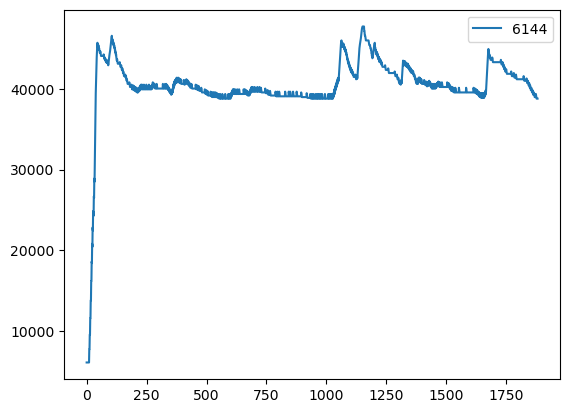

In [1]:
import pandas as pd

file = 'runs/2026_03_16_1309_tartan_pytorch_data_collecting/max_edges_count.txt'

df = pd.read_csv(file)
print(df.max())

df.plot()


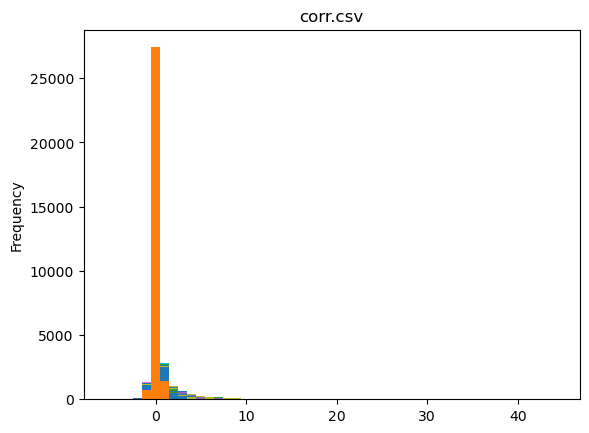

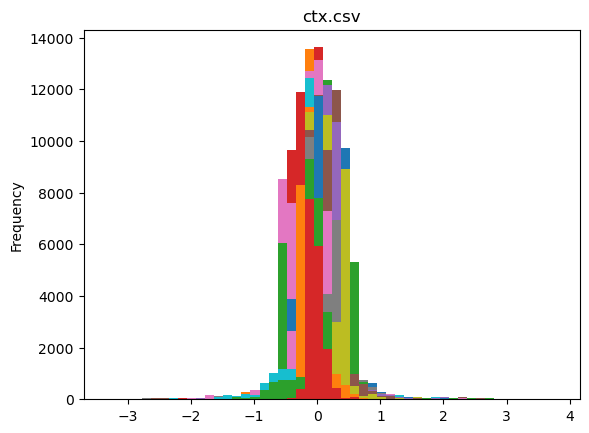

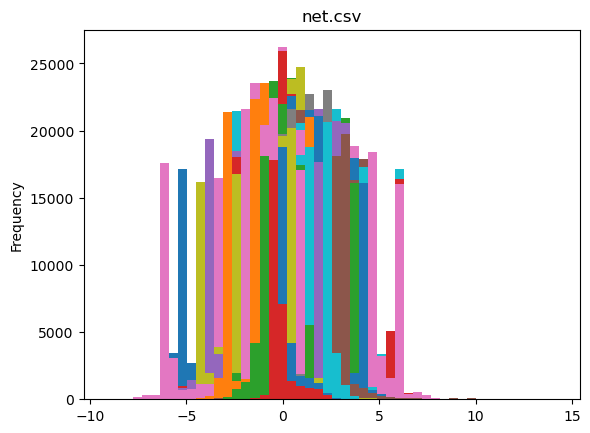

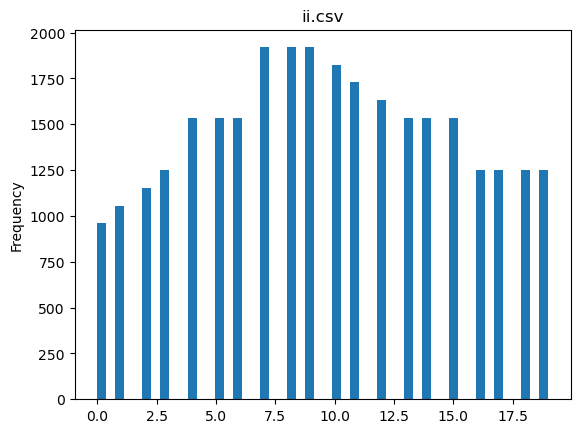

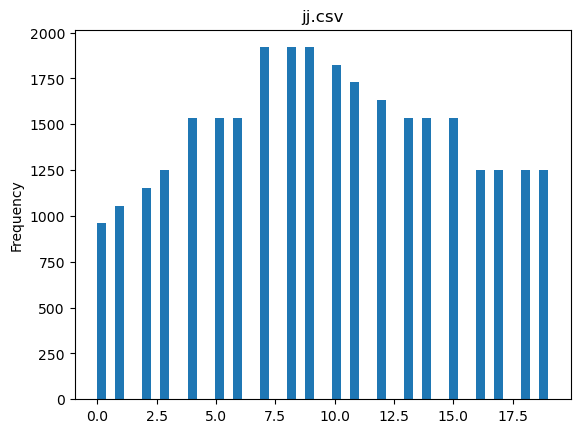

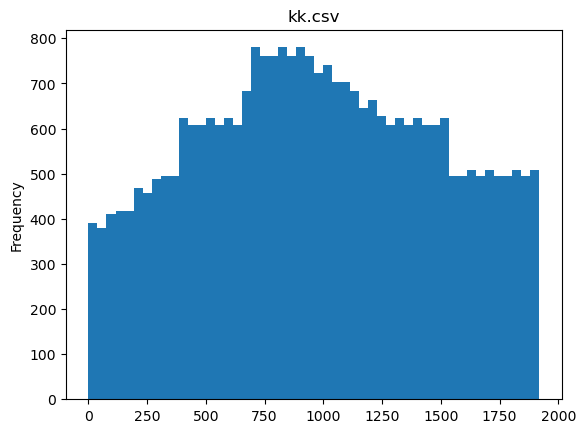

In [11]:
root = 'runs/2026_03_17_1553_tartan_mono_onnx_logging_values/'
files = ['corr.csv', 'ctx.csv', 'net.csv', 'ii.csv', 'jj.csv', 'kk.csv']

import os
import matplotlib.pyplot as plt

out_dir = "figures/input_values"
os.makedirs(out_dir, exist_ok=True)

for file in files:
    path = root + file
    df = pd.read_csv(path, index_col=0, header=0)
    
    ax = df.plot.hist(title=file, legend=False, bins=50)
    fig = ax.get_figure()
    
    # build a safe filename based on the CSV name
    base = os.path.splitext(os.path.basename(file))[0]
    out_path = os.path.join(out_dir, f"{base}_hist.png")
    
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


In [13]:
import torch 
from dpvo import fastba

patches_per_image = 96

pmem = mem = 36  # number of frames in memory
DIM = 384 # number of features per edge?
RES = 4 # resolution downscale factor
P = 3 # patch size
M = patches_per_image
IN_FEATS = 2 * 49 * P * P # 882
E = number_of_active_edges = 50000 # during ME0005 run, max value found to be 47712. So doubled, and inputs will be padded to match. 
# actual inputs
device = 'cuda'
net_dummy  = torch.randn(1, E, DIM, device=device, dtype=torch.float32)
inp_dummy  = torch.randn(1, E, DIM, device=device, dtype=torch.float32)
corr_dummy = torch.randn(1, E, IN_FEATS, device=device, dtype=torch.float32)
flow_dummy = torch.randn(1, E, 2, device=device, dtype=torch.float32)


num_blocks = (E / M) + 2
ii_dummy = torch.arange(num_blocks, device=device, dtype=torch.long).repeat_interleave(M)[:E] # source frame index
jj_dummy = torch.arange(num_blocks, device=device, dtype=torch.long).repeat_interleave(M)[M:E + M] # target frame index
kk_dummy = torch.arange(E, device=device, dtype=torch.long) % (M)     # flattened patch index

def neighbors(kk: torch.Tensor, jj: torch.Tensor):
    """
    PyTorch implementation of fastba.neighbors. For each element, returns the
    previous (ix) and next (jx) temporal neighbor index within the same kk group,
    when ordering by jj. -1 means no previous/next neighbor.
    Fully vectorized (no Python loops) so ONNX export is fast and trace-friendly.
    """
    # Sort by kk first, then jj (PyTorch has no lexsort; use composite key).
    jj_max = jj.max() + 1
    key = kk * jj_max + jj
    order = torch.argsort(key)
    n = kk.shape[0]
    device = kk.device
    ix = torch.full((n,), -1, dtype=torch.long, device=device)
    jx = torch.full((n,), -1, dtype=torch.long, device=device)
    ix[order[1:]] = order[:-1]
    jx[order[:-1]] = order[1:]
    return ix, jx

ix, jx = fastba.neighbors(kk_dummy, jj_dummy)
# ix, jx = neighbors(kk_dummy, jj_dummy)
print(f'ix shape: {ix.shape}')
print(f'jx shape: {jx.shape}')

mask_ix = (ix >= 0).float().reshape(1, -1, 1)
mask_jx = (jx >= 0).float().reshape(1, -1, 1)

print(f'mask_ix shape: {mask_ix.shape}')
print(f'mask_jx shape: {mask_jx.shape}')

net_1 = mask_ix * net_dummy[:,ix]
print(f'net_1 shape: {net_1.shape}')
net_2 = mask_jx * net_1[:,jx]
print(f'net_2 shape: {net_2.shape}')

i = 0
for ix_i, jx_i in zip(ix, jx):
    print(f'ix: {ix_i}, jx: {jx_i}')
    i += 1
    if i >= 200:
        break

# i = 0 
# for net_i in net_1[0,:,:]:
#     print(f'net_1_{i}: {net_i}')
#     i += 1
#     if i >= 200:
#         break



ix shape: torch.Size([50000])
jx shape: torch.Size([50000])
mask_ix shape: torch.Size([1, 50000, 1])
mask_jx shape: torch.Size([1, 50000, 1])
net_1 shape: torch.Size([1, 50000, 384])
net_2 shape: torch.Size([1, 50000, 384])
ix: -1, jx: 96
ix: -1, jx: 97
ix: -1, jx: 98
ix: -1, jx: 99
ix: -1, jx: 100
ix: -1, jx: 101
ix: -1, jx: 102
ix: -1, jx: 103
ix: -1, jx: 104
ix: -1, jx: 105
ix: -1, jx: 106
ix: -1, jx: 107
ix: -1, jx: 108
ix: -1, jx: 109
ix: -1, jx: 110
ix: -1, jx: 111
ix: -1, jx: 112
ix: -1, jx: 113
ix: -1, jx: 114
ix: -1, jx: 115
ix: -1, jx: 116
ix: -1, jx: 117
ix: -1, jx: 118
ix: -1, jx: 119
ix: -1, jx: 120
ix: -1, jx: 121
ix: -1, jx: 122
ix: -1, jx: 123
ix: -1, jx: 124
ix: -1, jx: 125
ix: -1, jx: 126
ix: -1, jx: 127
ix: -1, jx: 128
ix: -1, jx: 129
ix: -1, jx: 130
ix: -1, jx: 131
ix: -1, jx: 132
ix: -1, jx: 133
ix: -1, jx: 134
ix: -1, jx: 135
ix: -1, jx: 136
ix: -1, jx: 137
ix: -1, jx: 138
ix: -1, jx: 139
ix: -1, jx: 140
ix: -1, jx: 141
ix: -1, jx: 142
ix: -1, jx: 143
ix: -1, jx: 

In [1]:
from onnx import shape_inference
import onnx

model = onnx.load("onnx/update.onnx")
model = shape_inference.infer_shapes(model)

for v in model.graph.value_info:
    dims = [
        d.dim_value if d.dim_value != 0 else d.dim_param
        for d in v.type.tensor_type.shape.dim
    ]
    print("VALUE:", v.name, dims)


VALUE: /Add_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.0/MatMul_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.0/Add_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.1/Relu_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.2/MatMul_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.2/Add_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.3/LayerNormalization_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.4/Relu_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.5/MatMul_output_0 [1, 'num_edges', 384]
VALUE: /corr/corr.5/Add_output_0 [1, 'num_edges', 384]
VALUE: /Add_1_output_0 [1, 'num_edges', 384]
VALUE: /norm/LayerNormalization_output_0 [1, 'num_edges', 384]
VALUE: /ReduceMax_output_0 []
VALUE: /Constant_output_0 []
VALUE: /Add_2_output_0 []
VALUE: /Mul_output_0 ['num_edges']
VALUE: /Add_3_output_0 ['num_edges']
VALUE: /Shape_output_0 [1]
VALUE: /Constant_1_output_0 [1]
VALUE: /Gather_output_0 [1]
VALUE: /TopK_output_0 ['unk__0']
VALUE: /TopK_output_1 ['unk__1']
VALUE: /Shape_1_ou